In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, norm, pearsonr, spearmanr
import seaborn as sns

## Probablility

In [2]:
matches = pd.read_csv("C:\\Users\\Kolade\\Documents\\Datasets\\Matches\\matches.csv")
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [3]:
total_matches = len(matches)

winners = len(matches[matches['winner'] == 'Sunrisers Hyderabad'])
probability = winners/total_matches
print("Probablility of Mumbai Indians winning: {0:.2f}%".format(probability*100))

Probablility of Mumbai Indians winning: 6.60%


In [4]:
# probablility of team 2 and winner

# total_tosses = len(matches)
# batting_choice = len(matches[([matches['winner'] == 'Mumbai Indians']) & (matches['team1'] == 'Mumbai Indians')])
# probablility = batting_choice/total_tosses
# print("Probablility of Mumbai Indians winning: {0:.2f}%".format(probability*100))

In [5]:
total_tosses = len(matches)
same_winners = len(matches[matches['toss_winner'] == matches['winner']])

probablility_1 = same_winners/total_tosses
print("Probablility of team 2 winning: ", probablility_1*100)

Probablility of team 2 winning:  51.100628930817614


In [6]:
total_tosses = len(matches)
same_winners = len(matches[matches['team1'] == matches['winner']])

probabilility_2 = same_winners/total_tosses
print("Probablility of team 1 winning: {0:.2f}%".format(probabilility_2*100))

Probablility of team 1 winning: 44.65%


In [7]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               636 non-null    int64  
 1   season           636 non-null    int64  
 2   city             629 non-null    object 
 3   date             636 non-null    object 
 4   team1            636 non-null    object 
 5   team2            636 non-null    object 
 6   toss_winner      636 non-null    object 
 7   toss_decision    636 non-null    object 
 8   result           636 non-null    object 
 9   dl_applied       636 non-null    int64  
 10  winner           633 non-null    object 
 11  win_by_runs      636 non-null    int64  
 12  win_by_wickets   636 non-null    int64  
 13  player_of_match  633 non-null    object 
 14  venue            636 non-null    object 
 15  umpire1          635 non-null    object 
 16  umpire2          635 non-null    object 
 17  umpire3         

In [8]:
matches = matches.drop(columns = 'umpire3', axis=1)

## Descriptive Stats

In [9]:
matches.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets
count,636.000000,636.000000,636.000000,636.000000,636.000000
mean,318.500000,2012.490566,0.025157,13.682390,3.372642
std,183.741666,2.773026,0.156726,23.908877,3.420338
min,1.000000,2008.000000,0.000000,0.000000,0.000000
25%,159.750000,2010.000000,0.000000,0.000000,0.000000
50%,318.500000,2012.000000,0.000000,0.000000,4.000000
75%,477.250000,2015.000000,0.000000,20.000000,7.000000
max,636.000000,2017.000000,1.000000,146.000000,10.000000


In [10]:
print("SKew: ", skew(matches["win_by_runs"]))
print("Kurtosis: ", kurtosis(matches["win_by_runs"]))

SKew:  2.516111145778937
Kurtosis:  7.39024746917922


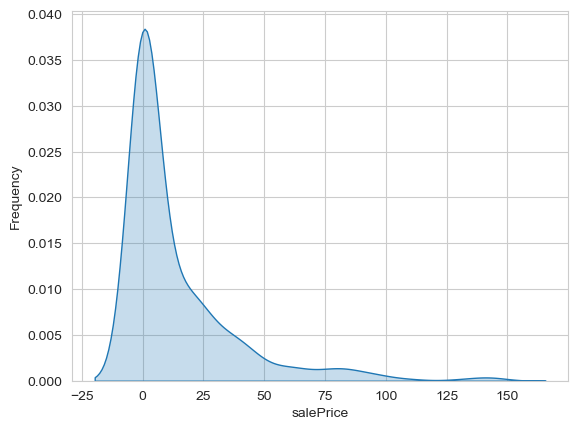

In [11]:
import seaborn as sns

sns.set_style("whitegrid")

sns.kdeplot(matches['win_by_runs'], fill=True)
plt.xlabel('salePrice')
plt.ylabel('Frequency')
plt.show();

In [96]:
df = pd.read_csv("C:\\Users\\Kolade\\Documents\\Datasets\\usa_fruit_export.csv")

In [97]:
df.head()

,code,state,category,total exports,beef,pork,poultry,dairy,fruits fresh,fruits proc,total fruits,veggies fresh,veggies proc,total veggies,corn,wheat,cotton
0,AL,Alabama,state,1390.63,34.4,10.6,481.0,4.06,8.0,17.1,25.11,5.5,8.9,14.33,34.9,70.0,317.61
1,AK,Alaska,state,13.31,0.2,0.1,0.0,0.19,0.0,0.0,0.00,0.6,1.0,1.56,0.0,0.0,0.00
2,AZ,Arizona,state,1463.17,71.3,17.9,0.0,105.48,19.3,41.0,60.27,147.5,239.4,386.91,7.3,48.7,423.95
3,AR,Arkansas,state,3586.02,53.2,29.4,562.9,3.53,2.2,4.7,6.88,4.4,7.1,11.45,69.5,114.5,665.44
4,CA,California,state,16472.88,228.7,11.1,225.4,929.95,2791.8,5944.6,8736.40,803.2,1303.5,2106.79,34.6,249.3,1064.95


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   code           50 non-null     object 
 1   state          50 non-null     object 
 2   category       50 non-null     object 
 3   total exports  50 non-null     float64
 4   beef           50 non-null     float64
 5   pork           50 non-null     float64
 6   poultry        50 non-null     float64
 7   dairy          50 non-null     float64
 8   fruits fresh   50 non-null     float64
 9   fruits proc    50 non-null     float64
 10  total fruits   50 non-null     float64
 11  veggies fresh  50 non-null     float64
 12  veggies proc   50 non-null     float64
 13  total veggies  50 non-null     float64
 14  corn           50 non-null     float64
 15  wheat          50 non-null     float64
 16  cotton         50 non-null     float64
dtypes: float64(14), object(3)
memory usage: 6.8+ KB


### Pearson, spearman and covariance

In [15]:
# Correlation is a way to measure how strongly two variables are related. In simple terms, it tells us whether two things increase or decrease together. For example:
# Do people who study more hours get higher scores?
# Does car weight affect fuel efficiency?

# In this case, does pork affect total export? 

l1 = df['pork']
l2 = df['total exports']

corr, pval = pearsonr(l1, l2)
print('Pearsons correlation: %.3f' % corr, pval)

Pearsons correlation: 0.540 5.1765902606259235e-05


In [16]:
# Spearman's Rank Correlation is a statistical measure of the strength and direction of the monotonic relationship between two continuous variables.
s1 = df['pork']
s2 = df['total exports']

corr, pval = spearmanr(s1, s2)

# print the result
print("Spearman's correlation coefficient:", corr)
print("p-value:", pval)

Spearman's correlation coefficient: 0.7018302867299411
p-value: 1.35955043333367e-08


In [17]:
# Covariance provides the measure of strength of correlation between two variable or more set of variables.
# It is like another form of correlation, it takes the form of coviarance matrix.

## transformations

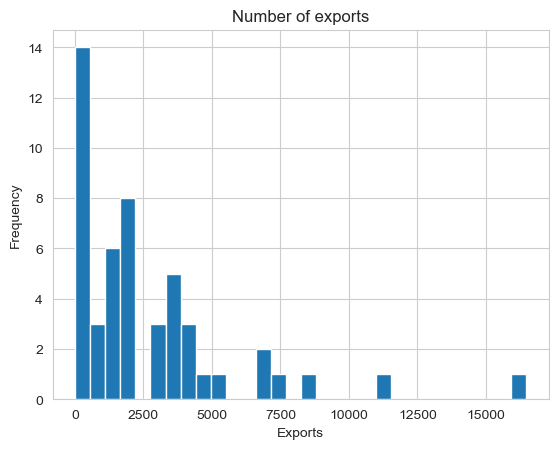

In [18]:
plt.hist(df['total exports'], bins=30)
plt.title('Number of exports')
plt.xlabel('Exports')
plt.ylabel('Frequency')
plt.show()

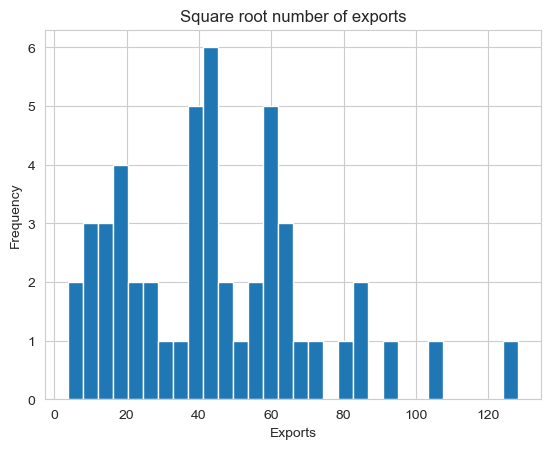

In [19]:
plt.hist(np.sqrt(df['total exports']), bins=30)

plt.title('Square root number of exports')
plt.xlabel('Exports')
plt.ylabel('Frequency')

plt.show()

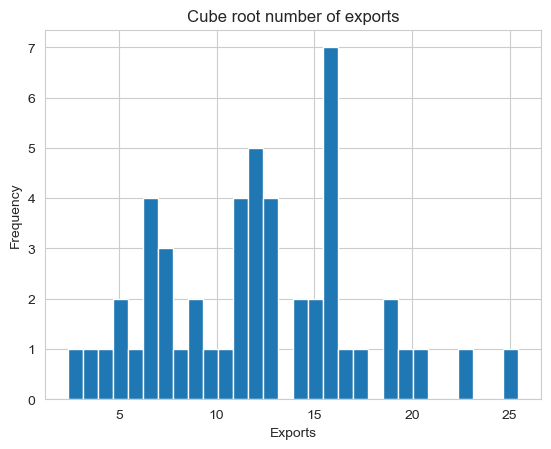

In [20]:
plt.hist(np.power(df['total exports'], 1/3), bins=30)

plt.title('Cube root number of exports')
plt.xlabel('Exports')
plt.ylabel('Frequency')

plt.show()

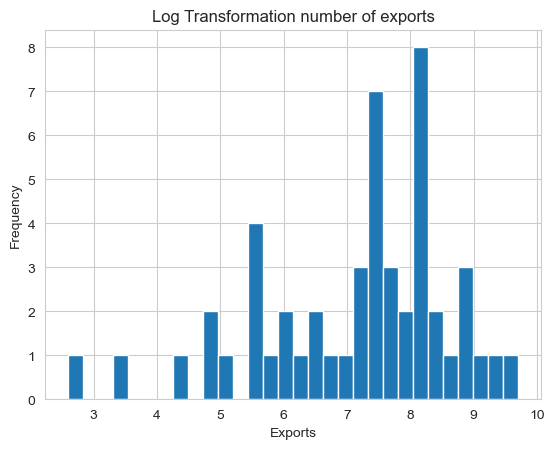

In [21]:
plt.hist(np.log(df['total exports']), bins=30)

plt.title('Log Transformation number of exports')
plt.xlabel('Exports')
plt.ylabel('Frequency')

plt.show()

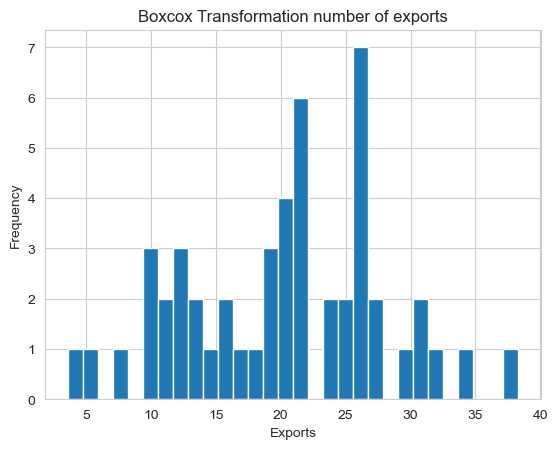

In [22]:
# Box-Cox
from scipy import stats

boxcox_TotalExports, _ = stats.boxcox(df['total exports'])
plt.hist(boxcox_TotalExports, bins=30)

plt.title('Boxcox Transformation number of exports')
plt.xlabel('Exports')
plt.ylabel('Frequency')

plt.show()

## Normal Distribution

2728.889
3144.8376078299225


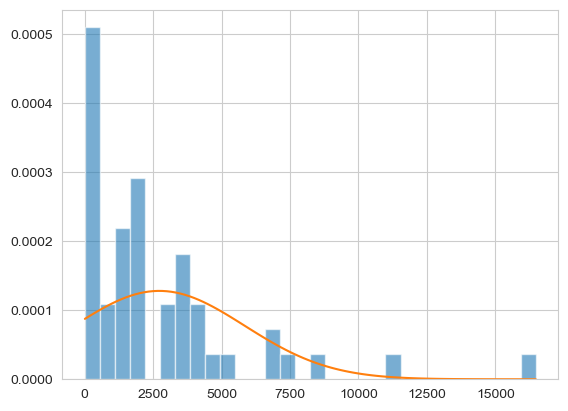

In [23]:
mu, sigma = norm.fit(df['total exports'])

plt.hist(df['total exports'], bins=30, density=True, alpha=0.6)
x = np.linspace(min(df['total exports']), max(df['total exports']), 100)
plt.plot(x, norm.pdf(x, mu, sigma))

mean = df['total exports'].mean()
std_dev = df['total exports'].std()
print(mean)
print(std_dev)

In [24]:
df_1 = pd.read_csv("C:\\Users\\Kolade\\Documents\\Datasets\\ds_salaries.csv")
df_1.head(10)

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
5,5,2020,EN,FT,Data Analyst,72000,USD,72000,US,100,US,L
6,6,2020,SE,FT,Lead Data Scientist,190000,USD,190000,US,100,US,S
7,7,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
8,8,2020,MI,FT,Business Data Analyst,135000,USD,135000,US,100,US,L
9,9,2020,SE,FT,Lead Data Engineer,125000,USD,125000,NZ,50,NZ,S


In [27]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [28]:
import scipy.stats as stats

salary_zscores = stats.zscore(df_1['salary'])
salary_zscores[:10]

0   -0.164605
1   -0.041475
2   -0.154885
3   -0.197008
4   -0.112761
5   -0.163309
6   -0.086839
7    6.918609
8   -0.122482
9   -0.128962
Name: salary, dtype: float64

In [29]:
df_1.salary_currency.value_counts()

salary_currency
USD    398
EUR     95
GBP     44
INR     27
CAD     18
JPY      3
PLN      3
TRY      3
CNY      2
MXN      2
HUF      2
DKK      2
SGD      2
BRL      2
AUD      2
CLP      1
CHF      1
Name: count, dtype: int64

In [80]:
df_2 = pd.read_csv("C:\\Users\\Kolade\\Documents\\Datasets\\Employee Attrition.csv")
df_2.head()

,Emp ID,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,dept,salary
0,1.0,0.38,0.53,2.0,157.0,3.0,0.0,0.0,sales,low
1,2.0,0.80,0.86,5.0,262.0,6.0,0.0,0.0,sales,medium
2,3.0,0.11,0.88,7.0,272.0,4.0,0.0,0.0,sales,medium
3,4.0,0.72,0.87,5.0,223.0,5.0,0.0,0.0,sales,low
4,5.0,0.37,0.52,2.0,159.0,3.0,0.0,0.0,sales,low


In [81]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15787 entries, 0 to 15786
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp ID                 14999 non-null  float64
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  float64
 4   average_montly_hours   14999 non-null  float64
 5   time_spend_company     14999 non-null  float64
 6   Work_accident          14999 non-null  float64
 7   promotion_last_5years  14999 non-null  float64
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(8), object(2)
memory usage: 1.2+ MB


### Correlation

In [32]:
numeric_df = df_2.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

                         Emp ID  satisfaction_level  last_evaluation  \
Emp ID                 1.000000            0.045841        -0.018168   
satisfaction_level     0.045841            1.000000         0.105021   
last_evaluation       -0.018168            0.105021         1.000000   
number_project        -0.012124           -0.142970         0.349333   
average_montly_hours  -0.009850           -0.020048         0.339742   
time_spend_company     0.144159           -0.100866         0.131591   
Work_accident          0.015931            0.058697        -0.007104   
promotion_last_5years  0.088994            0.025605        -0.008684   

                       number_project  average_montly_hours  \
Emp ID                      -0.012124             -0.009850   
satisfaction_level          -0.142970             -0.020048   
last_evaluation              0.349333              0.339742   
number_project               1.000000              0.417211   
average_montly_hours         0.41721

<Axes: >

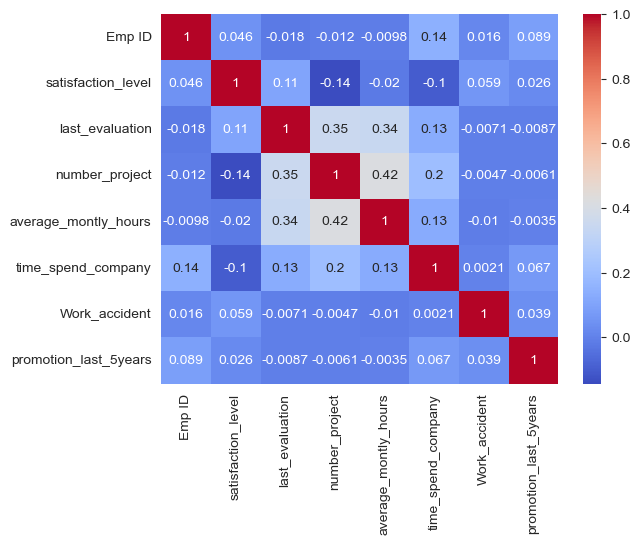

In [33]:
import seaborn as sns

corr = df_2.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [34]:
import random

result = [1,2,3,4,5,6]
rolled_value = random.choice(result)
print("random value: ", rolled_value)

random value:  1


In [33]:
# ttest_1samp(data['']) -- 1 sample t-test
# stats.ttest_ind() -- 2 sample t-test
# stats.ttest_rel() -- paired test
# ztest() and p-value
# stats.f_oneway -- anova

# Exploratory Data Analysis

Univariate Analysis: Histograms, box plots, summary statistics
Univariate analysis is the simplest form of data analysis that examines one variable at a time. 
The goal is to summarize, describe, and understand the distribution, patterns, and characteristics of that single variable without considering relationships with other variables.

For categorical variables: Bar charts, Pie charts, Frequency tables

For numerical variables: Histograms, Boxplots, Density plots

In [36]:
# Frequency Table
df_2['salary'].value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [37]:
frequency_table = pd.DataFrame({
    'Count': df_2['dept'].value_counts(),
    'Percentage': df_2['dept'].value_counts(normalize=True) * 100
})

print(frequency_table)

             Count  Percentage
dept                          
sales         4140   27.601840
technical     2720   18.134542
support       2229   14.860991
IT            1227    8.180545
product_mng    902    6.013734
marketing      858    5.720381
RandD          787    5.247016
accounting     767    5.113674
hr             739    4.926995
management     630    4.200280


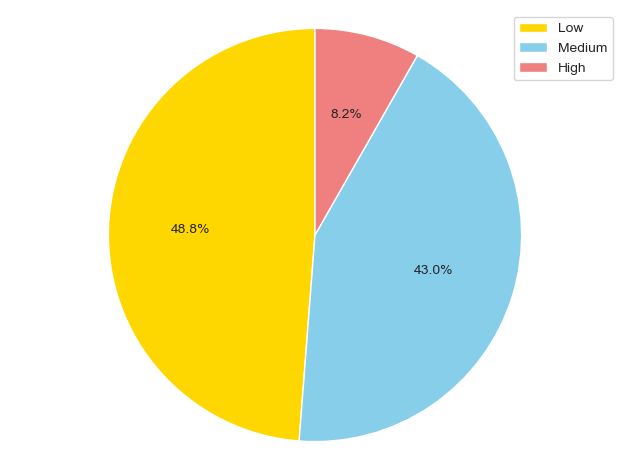

In [38]:
label = ['Low', 'Medium', 'High']
size = df_2['salary'].value_counts()
color = ['gold', 'skyblue', 'lightcoral']
patches, texts, auto = plt.pie(size, colors=color, startangle=90, autopct='%1.1f%%')
plt.legend(patches, label, loc='best')
plt.axis('equal')
plt.tight_layout()

In [39]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN


In [40]:
matches['winner'].value_counts()

winner
Mumbai Indians                 92
Chennai Super Kings            79
Kolkata Knight Riders          77
Royal Challengers Bangalore    73
Kings XI Punjab                70
Rajasthan Royals               63
Delhi Daredevils               62
Sunrisers Hyderabad            42
Deccan Chargers                29
Gujarat Lions                  13
Pune Warriors                  12
Rising Pune Supergiant         10
Kochi Tuskers Kerala            6
Rising Pune Supergiants         5
Name: count, dtype: int64

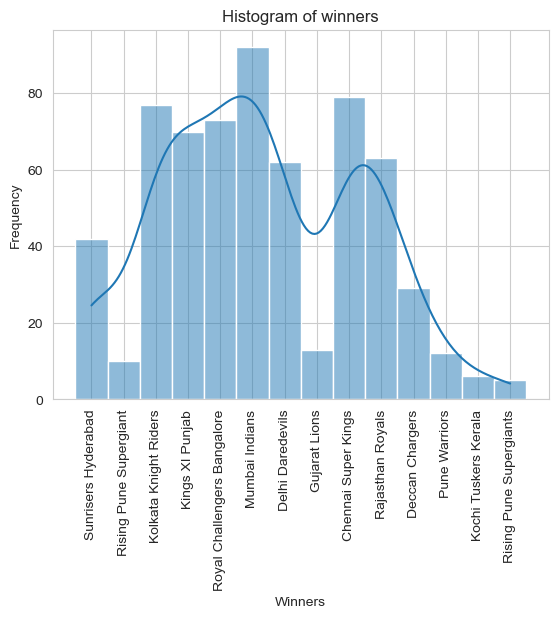

In [41]:
sns.set_style("whitegrid")
sns.histplot(matches['winner'], bins=14, kde=True)

plt.title("Histogram of winners")
plt.xlabel("Winners")
plt.ylabel("Frequency")

plt.xticks(rotation=90)
plt.show()

In [82]:
df_2.head()

,Emp ID,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,dept,salary
0,1.0,0.38,0.53,2.0,157.0,3.0,0.0,0.0,sales,low
1,2.0,0.80,0.86,5.0,262.0,6.0,0.0,0.0,sales,medium
2,3.0,0.11,0.88,7.0,272.0,4.0,0.0,0.0,sales,medium
3,4.0,0.72,0.87,5.0,223.0,5.0,0.0,0.0,sales,low
4,5.0,0.37,0.52,2.0,159.0,3.0,0.0,0.0,sales,low


<Axes: xlabel='average_montly_hours', ylabel='Density'>

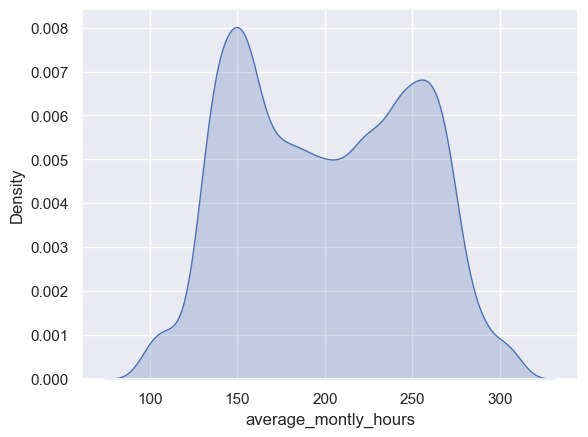

In [105]:
# Density plot

import seaborn as sns
sns.set()
sns.kdeplot(df_2["average_montly_hours"], fill=True)
# sns.kdeplot(df_2["satisfaction_level"], fill=True);

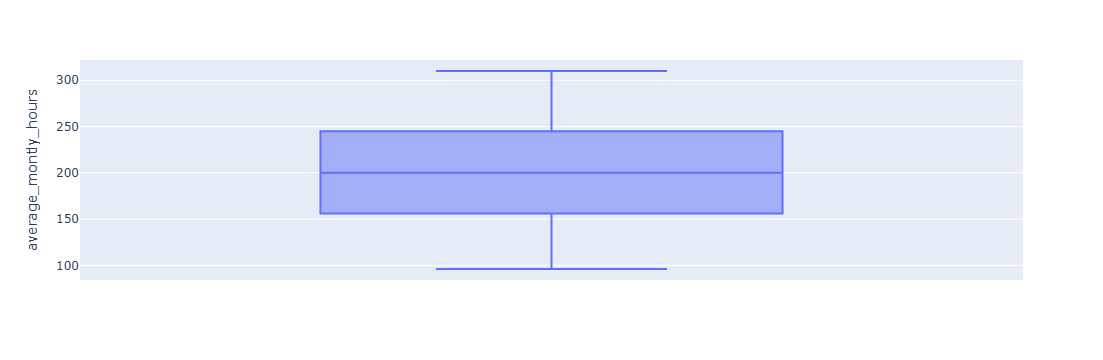

In [65]:
import plotly.express as px
fig = px.box(df_2, y="average_montly_hours")
fig.show();

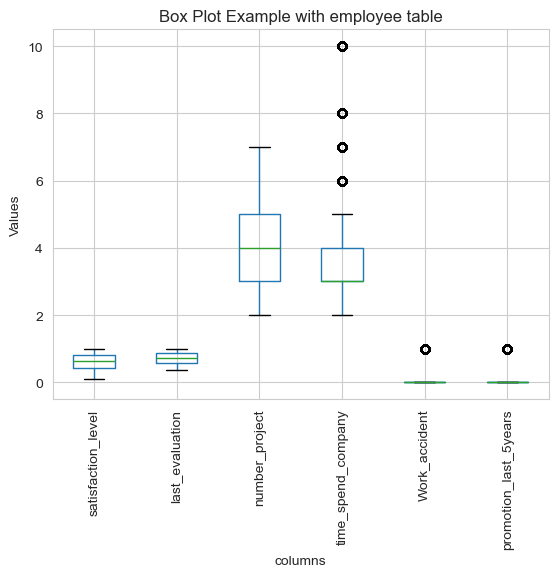

In [71]:
numeric_df = df_2.select_dtypes(include="number")
# numeric_df = numeric_df.iloc[:, 1:]
numeric_df = numeric_df.drop(df_2.columns[[0,4]], axis=1)

numeric_df.boxplot()

plt.title("Box Plot Example with employee table")
plt.xlabel("columns")
plt.ylabel("Values")

plt.xticks(rotation=90)
plt.show()

In [62]:
df_2.columns
# print(repr(df_2.columns[0]))

Index(['Emp ID', 'satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'dept', 'salary'],
      dtype='object')

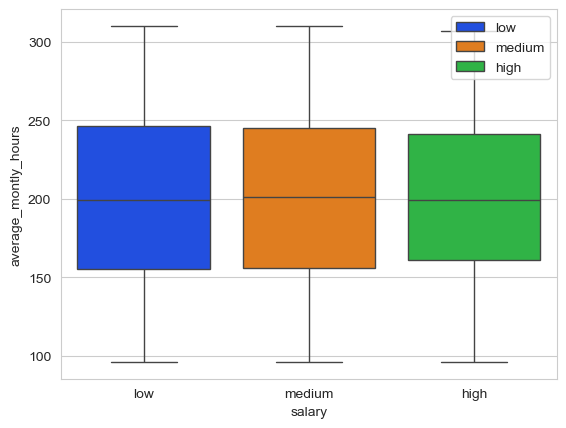

In [79]:
sns.boxplot(
    x='salary', 
    y='average_montly_hours', 
    data=df_2,
    palette='bright',
    hue='salary');
plt.legend(loc="upper right")

## Bivariate Analysis

Scatter plots, correlation matrices

## Cat vs Cat → cross-tabulations, stacked bar charts.

In [83]:
df_2['salary'].value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [84]:
df_2.head()


,Emp ID,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,dept,salary
0,1.0,0.38,0.53,2.0,157.0,3.0,0.0,0.0,sales,low
1,2.0,0.80,0.86,5.0,262.0,6.0,0.0,0.0,sales,medium
2,3.0,0.11,0.88,7.0,272.0,4.0,0.0,0.0,sales,medium
3,4.0,0.72,0.87,5.0,223.0,5.0,0.0,0.0,sales,low
4,5.0,0.37,0.52,2.0,159.0,3.0,0.0,0.0,sales,low


In [85]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15787 entries, 0 to 15786
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp ID                 14999 non-null  float64
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  float64
 4   average_montly_hours   14999 non-null  float64
 5   time_spend_company     14999 non-null  float64
 6   Work_accident          14999 non-null  float64
 7   promotion_last_5years  14999 non-null  float64
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(8), object(2)
memory usage: 1.2+ MB


In [86]:
df_2 = df_2.dropna(axis = 0)

In [112]:
df_2['dept'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [113]:
# len(df_2['dept'].unique())
# print((df_2['salary'] == "low").sum()) 
# df_2['average_montly_hours'].sum()
# df_2.head()
pivot_df = pd.pivot_table(
    df_2,
    values="average_montly_hours",
    index="dept",
    columns="salary", 
    aggfunc="sum", 
    fill_value=0)
print(pivot_df)

salary          high       low    medium
dept                                    
IT           16179.0  122642.0  109298.0
RandD        10187.0   72344.0   75499.0
accounting   15237.0   71564.0   67491.0
hr            9408.0   67823.0   69597.0
management   45056.0   36134.0   45597.0
marketing    14846.0   82204.0   74023.0
product_mng  13235.0   90673.0   76461.0
sales        54117.0  420562.0  357094.0
support      28762.0  227940.0  190788.0
technical    40209.0  278605.0  231979.0


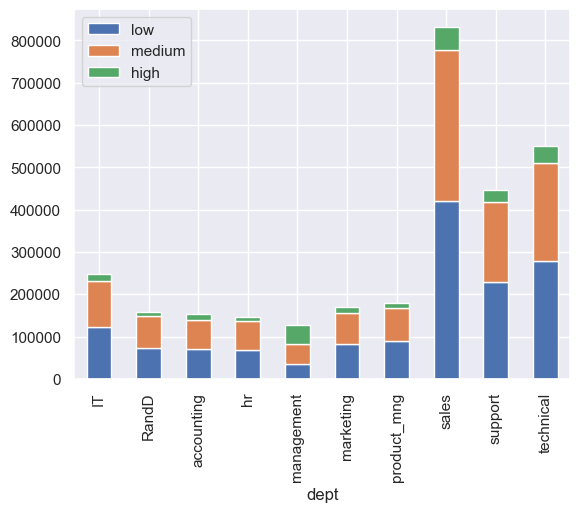

In [118]:

# a = df_2.loc[df_2['salary'] == "low", "average_montly_hours"].sum()
# b = df_2.loc[df_2['salary'] == "medium", "average_montly_hours"].sum()
# c = df_2.loc[df_2['salary'] == "high", "average_montly_hours"].sum()
# a = [sales_sum, accounting_sum, technical_sum, support_sum, mgt_sum, it_sum, prod_sum, marketing_sum, rand_sum]

# ax = df_2.set_index("dept")

# x = np.arange(len())
# departments = df_2['dept'].unique()
# x = np.arange(len(departments))
# x = range(11)
pivot_df = pivot_df[["low", "medium", "high"]]

pivot_df.plot(kind="bar", stacked=True)
# plt.bar(x, a, color='b', label='low')
# plt.bar(x, b, color='r', bottom=a, label='Medium')
# plt.bar(x, c, color='g', bottom=a+b, label='High')
# plt.xticks(x, departments, rotation=90)
plt.legend()
plt.show();

# df_2.plot(kind="bar", stacked=True)
# plt.ylabel("Values")
# plt.title("Stacked Bar Chart")
# plt.show()

In [ ]:
fig, axes = plt.subplots(6, 6, figsize=(15,10))
for idx, feature in enumerate(numCol_df.columns):
    numCol_df.plot(feature, "SalePrice", subplots=True, kind="scatter",ax=axes[idx // 6,idx % 6])
fig.tight_layout()
plt.show()

## MultiVariate Analysis

In [57]:
df_1.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


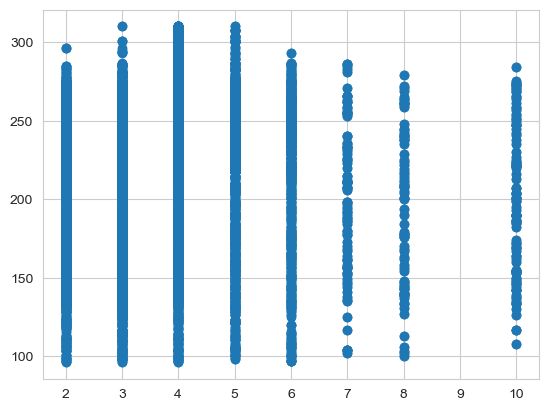

In [61]:
x = df_2['time_spend_company']
y = df_2['average_montly_hours']
plt.scatter(x,y)

In [99]:
df.head()

,code,state,category,total exports,beef,pork,poultry,dairy,fruits fresh,fruits proc,total fruits,veggies fresh,veggies proc,total veggies,corn,wheat,cotton
0,AL,Alabama,state,1390.63,34.4,10.6,481.0,4.06,8.0,17.1,25.11,5.5,8.9,14.33,34.9,70.0,317.61
1,AK,Alaska,state,13.31,0.2,0.1,0.0,0.19,0.0,0.0,0.00,0.6,1.0,1.56,0.0,0.0,0.00
2,AZ,Arizona,state,1463.17,71.3,17.9,0.0,105.48,19.3,41.0,60.27,147.5,239.4,386.91,7.3,48.7,423.95
3,AR,Arkansas,state,3586.02,53.2,29.4,562.9,3.53,2.2,4.7,6.88,4.4,7.1,11.45,69.5,114.5,665.44
4,CA,California,state,16472.88,228.7,11.1,225.4,929.95,2791.8,5944.6,8736.40,803.2,1303.5,2106.79,34.6,249.3,1064.95


In [100]:
sns.set_style('darkgrid')
sns.set(font_scale=1.3)
# df.drop(["code", "state", "category"], axis=1, inplace=True)
df.head()
# data.info()

,code,state,category,total exports,beef,pork,poultry,dairy,fruits fresh,fruits proc,total fruits,veggies fresh,veggies proc,total veggies,corn,wheat,cotton
0,AL,Alabama,state,1390.63,34.4,10.6,481.0,4.06,8.0,17.1,25.11,5.5,8.9,14.33,34.9,70.0,317.61
1,AK,Alaska,state,13.31,0.2,0.1,0.0,0.19,0.0,0.0,0.00,0.6,1.0,1.56,0.0,0.0,0.00
2,AZ,Arizona,state,1463.17,71.3,17.9,0.0,105.48,19.3,41.0,60.27,147.5,239.4,386.91,7.3,48.7,423.95
3,AR,Arkansas,state,3586.02,53.2,29.4,562.9,3.53,2.2,4.7,6.88,4.4,7.1,11.45,69.5,114.5,665.44
4,CA,California,state,16472.88,228.7,11.1,225.4,929.95,2791.8,5944.6,8736.40,803.2,1303.5,2106.79,34.6,249.3,1064.95


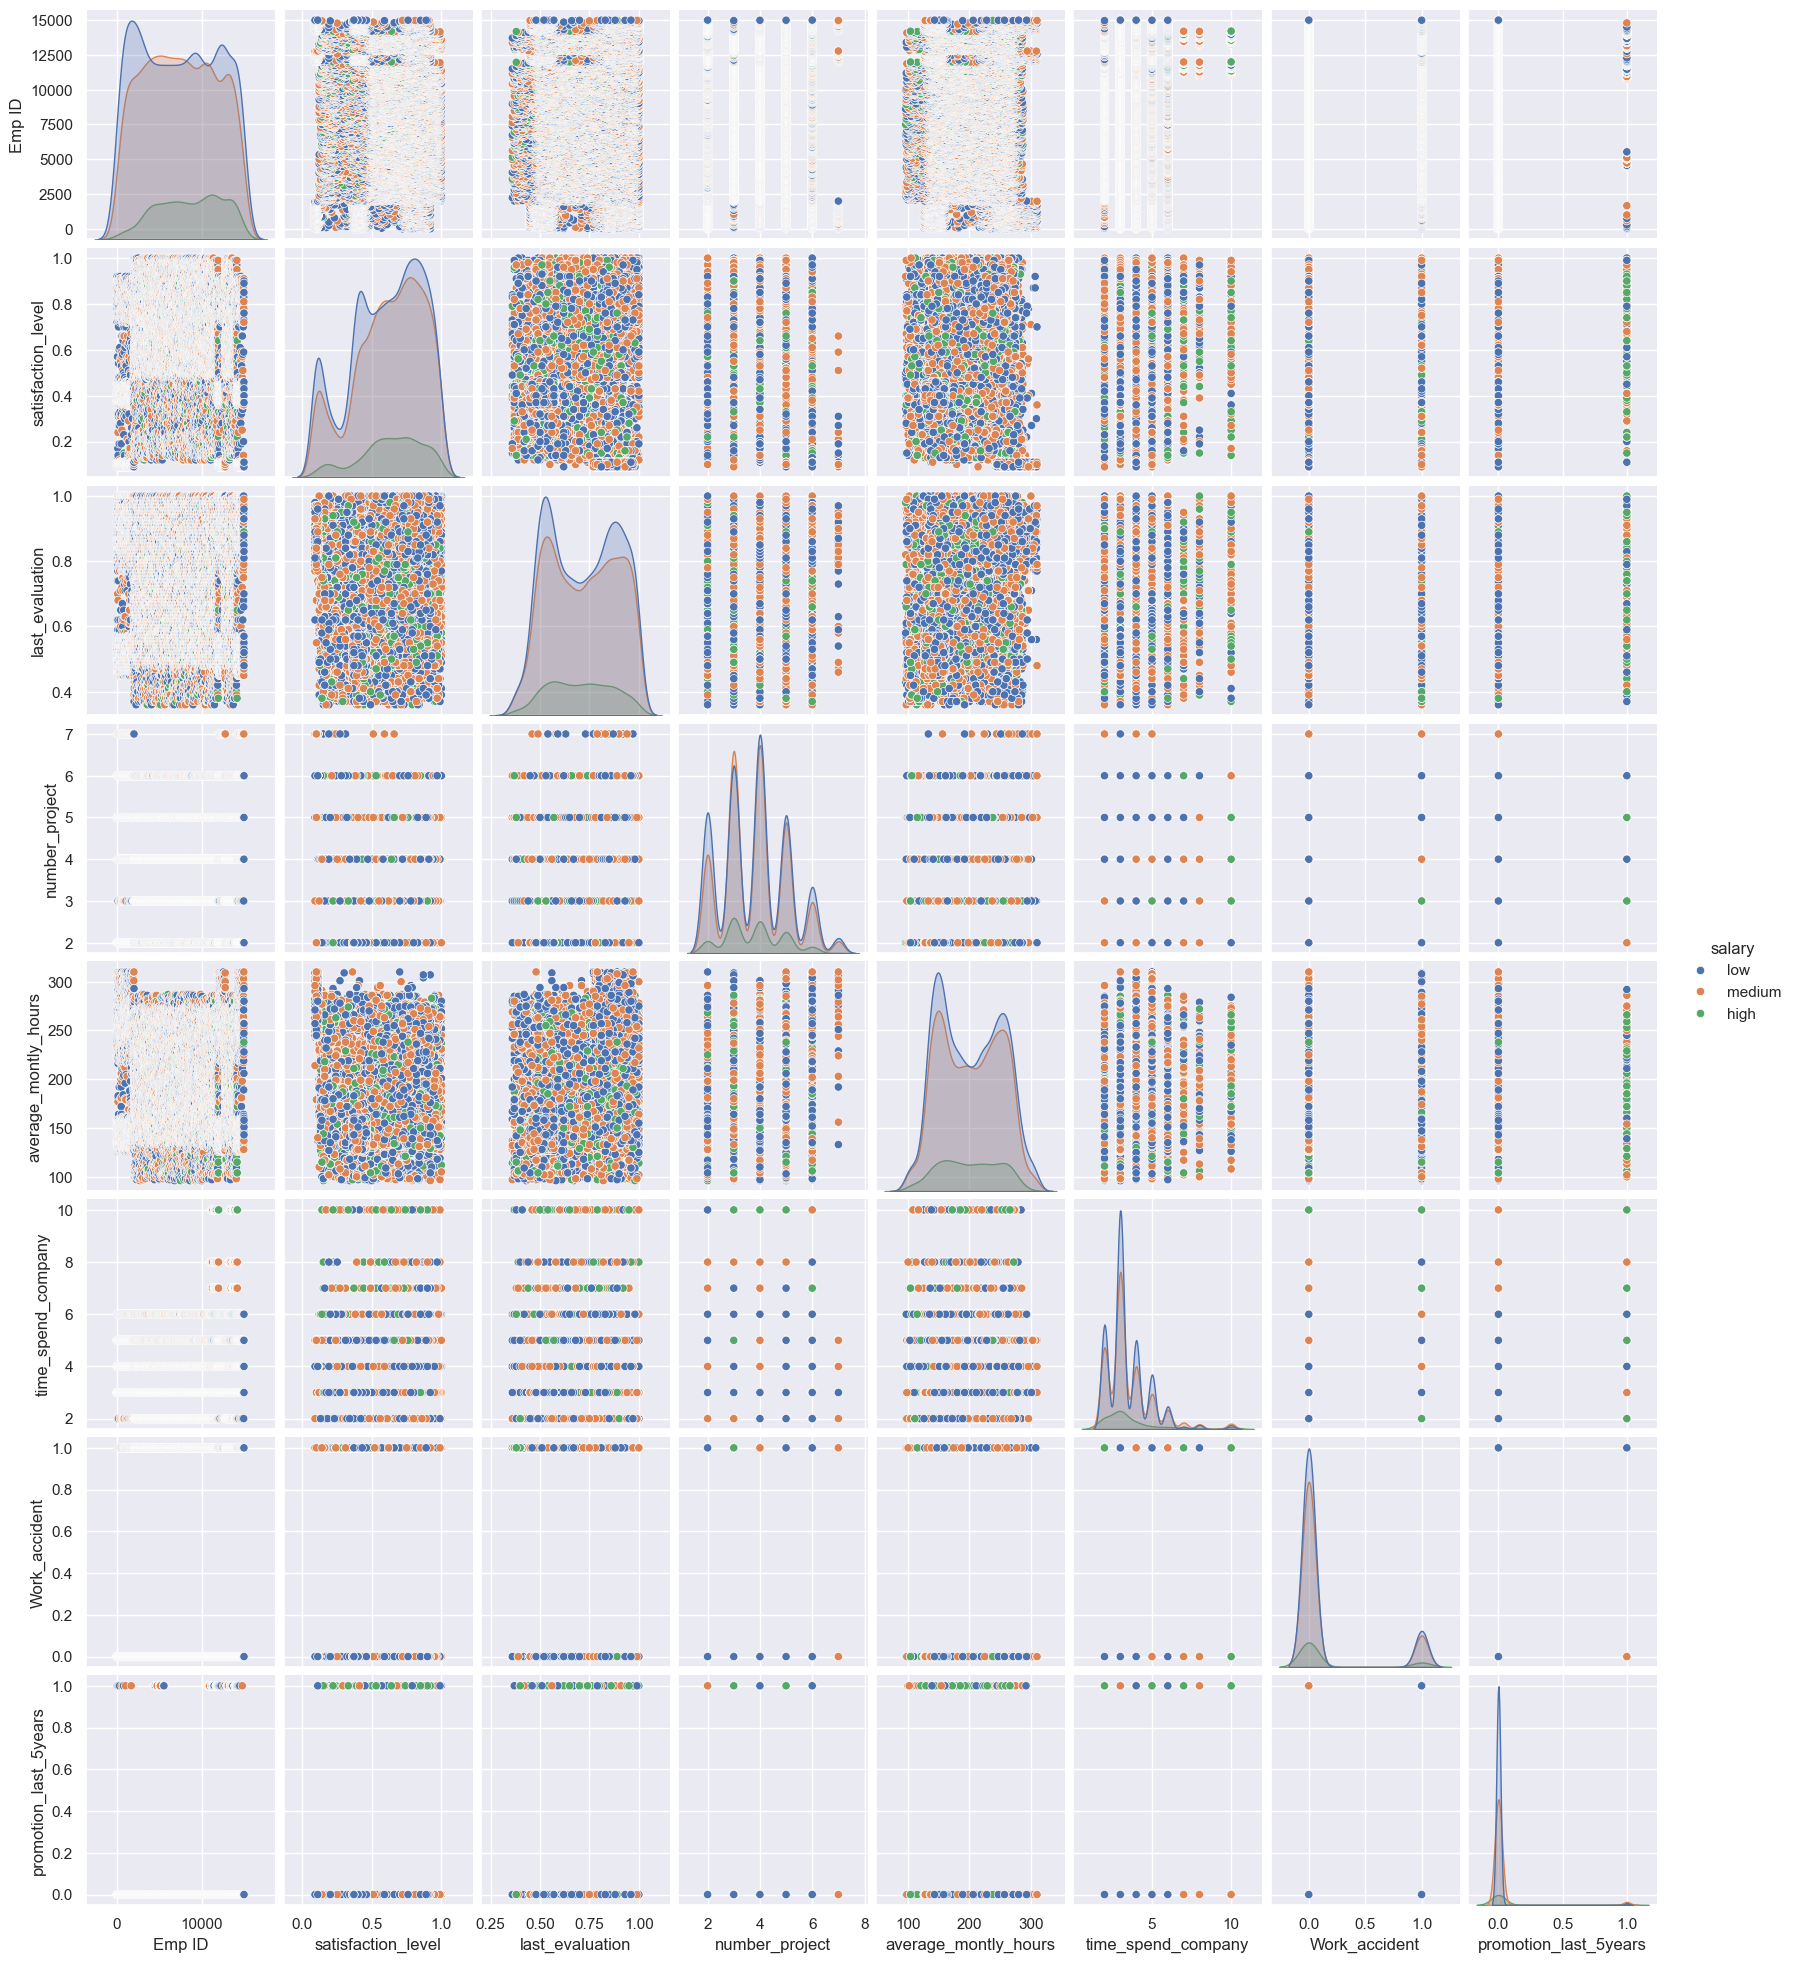

In [107]:
sns.pairplot(data=df_2,
            # aspect=.85,
            hue='salary'
            )

### The art of story telling
DA Best Practices: Structured Approach

Think of EDA as a step-by-step investigation of your dataset. A good structure looks like this:

1. Understand the Context

Know the business problem / research question.

Identify the type of data (time series, tabular, categorical-heavy, text, etc.).

2. Data Collection & Import

Load data into a DataFrame.

Check dimensions (df.shape), preview rows (df.head()).

3. Data Cleaning

Handle missing values (isnull(), imputation, dropping).

Handle duplicates (drop_duplicates).

Check and fix data types (categorical vs numeric vs datetime).

Normalize text fields (case, whitespace, typos).

4. Univariate Analysis

Understand each variable independently.

For numerical: histograms, boxplots, summary stats (mean, median, std).

For categorical: frequency tables, bar plots.

5. Bivariate Analysis

Look at relationships between two variables.

Num vs Num → scatter plots, correlation heatmaps.

Cat vs Num → boxplots, violin plots, group summaries.

Cat vs Cat → cross-tabulations, stacked bar charts.

6. Multivariate Analysis

Look at interactions between 3+ variables.

Use pairplots, grouped summaries, PCA (if dimensionality is high).

7. Outliers & Anomalies

Detect via boxplots, z-scores, IQR method.

Decide whether to keep, transform, or remove.

8. Feature Engineering Ideas

Based on insights: create new features (e.g., age groups, ratios, lag features in time series).

9. Summarize Key Insights

End with a set of concise findings: distributions, correlations, potential drivers of target variable.

🔹 EDA as Storytelling

EDA becomes much more powerful if you present it as a narrative instead of just dumping plots.

How to turn EDA into a story:

Set the Scene → Define the problem and introduce the dataset.
“We want to understand customer churn. Our dataset has 5,000 customers with demographic and service usage features.”

Introduce the Characters (Variables) → Describe distributions and main variables.
“Most customers are aged 30–45, with 60% male and 40% female.”

Explore Relationships (Interactions) → Show how variables interact.
“Churn is higher among customers with month-to-month contracts and lower among those with yearly contracts.”

Reveal Conflicts / Surprises (Anomalies, Outliers)
“Interestingly, some high-value customers still churn despite long tenure — indicating possible service issues.”

Resolution / Takeaways
“Key drivers of churn seem to be contract type, tenure, and service complaints. These will guide our feature engineering and modeling.”

🔹 Tips for Effective EDA

Keep it iterative → EDA is about curiosity, test hypotheses as you go.

Use visuals over tables → Plots tell a story faster than numbers.

Document insights → Not just what you plotted, but what it means.

Think like an audience → Ask: if I showed this to a non-technical stakeholder, would it make sense?

Don’t overfit EDA → The goal is exploration, not squeezing meaning from every tiny pattern.